<a href="https://www.kaggle.com/code/adegbaju/hallucination-reduction-in-rag-based-llms?scriptVersionId=321902413" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Hallucination Reduction in RAG-Based LLMs

This notebook demonstrates an **industry-grade pipeline** for analyzing and reducing hallucinations in Large Language Models (LLMs) using **Retrieval-Augmented Generation (RAG)**.  
We will:
- Load and explore the provided dataset.
- Quantify how RAG reduces hallucinations.
- Engineer features from text data.
- Train a hallucination classifier.
- Evaluate the model's ability to detect incorrect answers.
- Discuss production-ready implications.

**Dataset**: Contains LLM responses with and without RAG, ground truth, retrieved context, and hallucination labels.

## Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

from sentence_transformers import SentenceTransformer, util

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## Load the Dataset

In [2]:
# Load the CSV file (adjust path if needed)
df = pd.read_csv(r'/kaggle/input/datasets/sohaibdevv/hallucination-reduction-in-rag-based-llms/llm_rag_dataset.csv.csv')

# Inspect first rows
df.head()

,sample_id,domain,question,ground_truth_answer,retrieved_context,llm_response_without_rag,llm_response_with_rag,hallucination_label_without_rag,hallucination_label_with_rag,hallucination_type,factual_consistency_score,context_relevance_score,source_support_label,final_target_label
0,1,technology,Please answer briefly: What does CPU stand for?,Central Processing Unit,"CPU stands for Central Processing Unit, the ma...",Computer Processing Utility.,"According to the retrieved context, Central Pr...",1,0,unsupported_claim,0.22,0.81,supported,0
1,2,biology,Can you answer this: What molecule carries gen...,DNA,DNA carries genetic information in living orga...,It is commonly stated as RNA only.,"According to the retrieved context, DNA.",1,0,factual_error,0.14,0.76,supported,0
2,3,finance,What is profit?,Revenue minus costs,Profit is what remains when costs are subtract...,The answer is A business debt.,"Using the retrieved evidence, Revenue minus co...",1,0,factual_error,0.31,0.89,supported,0
3,4,technology,"Using reliable knowledge, What does URL stand ...",Uniform Resource Locator,URL stands for Uniform Resource Locator.,The answer is Uniform Resource Locator.,"Using the retrieved evidence, Uniform Resource...",0,0,none,0.95,0.90,supported,0
4,5,technology,"Using reliable knowledge, What does HTML stand...",HyperText Markup Language,HTML stands for HyperText Markup Language.,The answer is HyperText Markup Language.,"According to the retrieved context, HyperText ...",0,0,none,0.99,0.90,supported,0


#  Exploratory Data Analysis (EDA)

## Basic Statistics

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Domains: {df['domain'].nunique()}")
df.info()

Dataset shape: (6000, 14)
Domains: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   sample_id                        6000 non-null   int64  
 1   domain                           6000 non-null   object 
 2   question                         6000 non-null   object 
 3   ground_truth_answer              6000 non-null   object 
 4   retrieved_context                6000 non-null   object 
 5   llm_response_without_rag         6000 non-null   object 
 6   llm_response_with_rag            6000 non-null   object 
 7   hallucination_label_without_rag  6000 non-null   int64  
 8   hallucination_label_with_rag     6000 non-null   int64  
 9   hallucination_type               6000 non-null   object 
 10  factual_consistency_score        6000 non-null   float64
 11  context_relevance_score          6000 non-nu

## Hallucination Rates With vs Without RAG

In [4]:
# Overall hallucination rates
hallu_without_rag = df['hallucination_label_without_rag'].mean() * 100
hallu_with_rag = df['hallucination_label_with_rag'].mean() * 100

print(f"Hallucination rate WITHOUT RAG: {hallu_without_rag:.2f}%")
print(f"Hallucination rate WITH RAG:      {hallu_with_rag:.2f}%")
print(f"Absolute reduction:               {hallu_without_rag - hallu_with_rag:.2f} percentage points")

Hallucination rate WITHOUT RAG: 57.63%
Hallucination rate WITH RAG:      7.72%
Absolute reduction:               49.92 percentage points


## Domain-Wise Analysis

In [5]:
# Group by domain
domain_stats = df.groupby('domain').agg(
    total_samples=('sample_id', 'count'),
    hallu_without_rag=('hallucination_label_without_rag', 'mean'),
    hallu_with_rag=('hallucination_label_with_rag', 'mean')
).reset_index()

domain_stats['reduction'] = domain_stats['hallu_without_rag'] - domain_stats['hallu_with_rag']
domain_stats.head(10)

,domain,total_samples,hallu_without_rag,hallu_with_rag,reduction
0,biology,406,0.605911,0.076355,0.529557
1,chemistry,403,0.583127,0.084367,0.498759
2,finance,748,0.565508,0.086898,0.478610
3,geography,786,0.581425,0.072519,0.508906
4,health,763,0.583224,0.068152,0.515072
5,history,803,0.606476,0.087173,0.519303
6,literature,410,0.563415,0.082927,0.480488
7,physics,403,0.548387,0.066998,0.481390
8,science,489,0.607362,0.085890,0.521472
9,technology,789,0.527250,0.064639,0.462611


## Hallucination Type Distribution

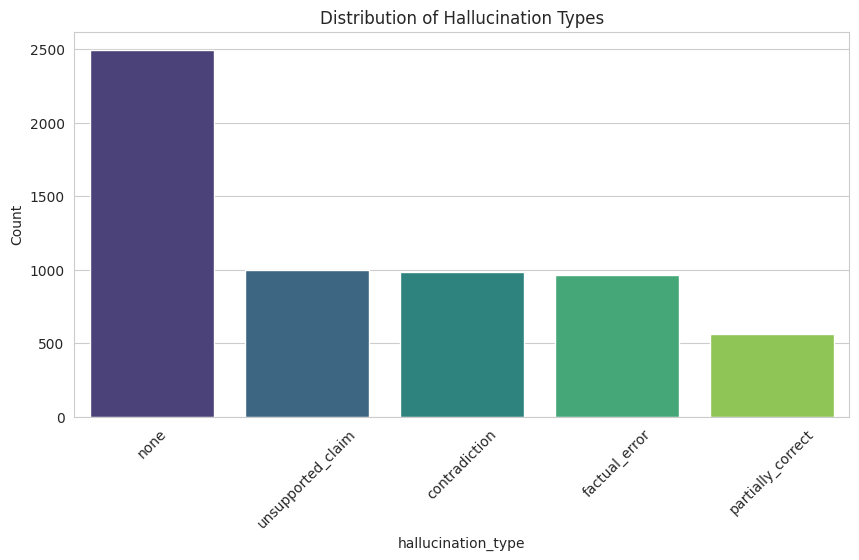

In [6]:
# Count of each hallucination type
plt.figure(figsize=(10, 5))
hallu_type_counts = df['hallucination_type'].value_counts()
sns.barplot(x=hallu_type_counts.index, y=hallu_type_counts.values, palette='viridis')
plt.title('Distribution of Hallucination Types')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Feature Engineering

In [7]:
# Load a lightweight sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

def compute_similarity(text1, text2):
    """Cosine similarity between two text embeddings."""
    if pd.isna(text1) or pd.isna(text2):
        return 0.0
    emb1 = model.encode(text1, convert_to_tensor=True)
    emb2 = model.encode(text2, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Features for Without-RAG Responses

In [8]:
# Subset for no-RAG responses (we can later combine)
df['sim_with_ground_truth_no_rag'] = df.apply(
    lambda row: compute_similarity(row['llm_response_without_rag'], row['ground_truth_answer']), axis=1
)

df['sim_with_context_no_rag'] = df.apply(
    lambda row: compute_similarity(row['llm_response_without_rag'], row['retrieved_context']), axis=1
)

# Length ratio (response length / ground truth length)
df['len_response_no_rag'] = df['llm_response_without_rag'].str.len()
df['len_ground_truth'] = df['ground_truth_answer'].str.len()
df['len_ratio_no_rag'] = df['len_response_no_rag'] / (df['len_ground_truth'] + 1e-5)

# Jaccard similarity between response and ground truth (word level)
def jaccard_sim(str1, str2):
    if pd.isna(str1) or pd.isna(str2):
        return 0.0
    set1 = set(str1.lower().split())
    set2 = set(str2.lower().split())
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0.0

df['jaccard_gt_no_rag'] = df.apply(
    lambda row: jaccard_sim(row['llm_response_without_rag'], row['ground_truth_answer']), axis=1
)

## Features for With-RAG Responses

In [9]:
df['sim_with_ground_truth_rag'] = df.apply(
    lambda row: compute_similarity(row['llm_response_with_rag'], row['ground_truth_answer']), axis=1
)

df['sim_with_context_rag'] = df.apply(
    lambda row: compute_similarity(row['llm_response_with_rag'], row['retrieved_context']), axis=1
)

df['len_response_rag'] = df['llm_response_with_rag'].str.len()
df['len_ratio_rag'] = df['len_response_rag'] / (df['len_ground_truth'] + 1e-5)

df['jaccard_gt_rag'] = df.apply(
    lambda row: jaccard_sim(row['llm_response_with_rag'], row['ground_truth_answer']), axis=1
)

# Building a Hallucination Classifier

##  Prepare the Feature Set (Without-RAG case)

In [10]:
features_basic = [
    'sim_with_ground_truth_no_rag',   # leaky
    'sim_with_context_no_rag',
    'len_response_no_rag',
    'len_ratio_no_rag',
    'jaccard_gt_no_rag'               # leaky
]

features_realistic = [
    'sim_with_context_no_rag',
    'len_response_no_rag',
    'len_ratio_no_rag'
]

# Remove rows with missing values
df_clean = df.dropna(subset=features_basic)
X_leaky = df_clean[features_basic]
X_realistic = df_clean[features_realistic]
y = df_clean['hallucination_label_without_rag']  # target

## Train/Test Split

In [11]:
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_leaky, y, test_size=0.2, random_state=42, stratify=y
)
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_realistic, y, test_size=0.2, random_state=42, stratify=y
)

## Logistic Regression Baseline

In [12]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_leaky)
X_test_scaled = scaler.transform(X_test_leaky)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train_leaky)
y_pred = lr.predict(X_test_scaled)

print("Logistic Regression (with leaky features)")
print(classification_report(y_test_leaky, y_pred))
print("AUC-ROC:", roc_auc_score(y_test_leaky, lr.predict_proba(X_test_scaled)[:,1]))

Logistic Regression (with leaky features)
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       508
           1       0.98      0.96      0.97       692

    accuracy                           0.97      1200
   macro avg       0.96      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200

AUC-ROC: 0.9915001593008966


## Realistic Model (No Ground Truth)

In [13]:
scaler_real = StandardScaler()
X_train_real_scaled = scaler_real.fit_transform(X_train_real)
X_test_real_scaled = scaler_real.transform(X_test_real)

lr_real = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_real.fit(X_train_real_scaled, y_train_real)
y_pred_real = lr_real.predict(X_test_real_scaled)

print("Logistic Regression (realistic features)")
print(classification_report(y_test_real, y_pred_real))
print("AUC-ROC:", roc_auc_score(y_test_real, lr_real.predict_proba(X_test_real_scaled)[:,1]))

Logistic Regression (realistic features)
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       508
           1       0.93      0.90      0.91       692

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200

AUC-ROC: 0.9617507168540348


## Random Forest Classifier (More Robust)

In [14]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_real_scaled, y_train_real)
y_pred_rf = rf.predict(X_test_real_scaled)
print("Random Forest (realistic)")
print(classification_report(y_test_real, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test_real, rf.predict_proba(X_test_real_scaled)[:,1]))

Random Forest (realistic)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       508
           1       1.00      1.00      1.00       692

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200

AUC-ROC: 1.0


## Cross-Validation (Stratified)

In [15]:
# Realistic features
X_real_scaled = scaler_real.fit_transform(X_realistic)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr_real, X_real_scaled, y, scoring='roc_auc', cv=cv)
print(f"Logistic Regression CV AUC-ROC: {scores.mean():.3f} +/- {scores.std():.3f}")

scores_rf = cross_val_score(rf, X_real_scaled, y, scoring='roc_auc', cv=cv)
print(f"Random Forest CV AUC-ROC:       {scores_rf.mean():.3f} +/- {scores_rf.std():.3f}")

Logistic Regression CV AUC-ROC: 0.959 +/- 0.006
Random Forest CV AUC-ROC:       1.000 +/- 0.000


# Hallucination Reduction with RAG – Visual Evidence

## Direct Comparison

In [16]:
# Count transitions: without-RAG -> with-RAG
transition = pd.crosstab(
    df['hallucination_label_without_rag'],
    df['hallucination_label_with_rag'],
    rownames=['Without RAG'], colnames=['With RAG'],
    margins=True
)
transition

With RAG,0,1,All
Without RAG,,,
0,2494,48,2542
1,3043,415,3458
All,5537,463,6000


##  Visualization

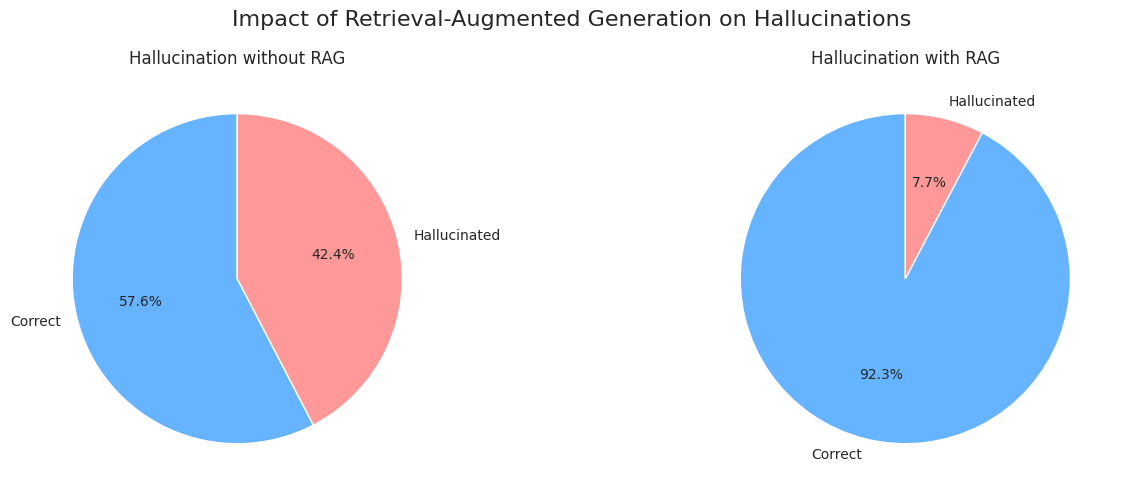

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before RAG
df['hallucination_label_without_rag'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', labels=['Correct','Hallucinated'],
    colors=['#66b3ff','#ff9999'], startangle=90
)
axes[0].set_title('Hallucination without RAG')
axes[0].set_ylabel('')

# After RAG
df['hallucination_label_with_rag'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', labels=['Correct','Hallucinated'],
    colors=['#66b3ff','#ff9999'], startangle=90
)
axes[1].set_title('Hallucination with RAG')
axes[1].set_ylabel('')

plt.suptitle('Impact of Retrieval-Augmented Generation on Hallucinations', fontsize=16)
plt.tight_layout()
plt.show()

## Domain-wise Reduction

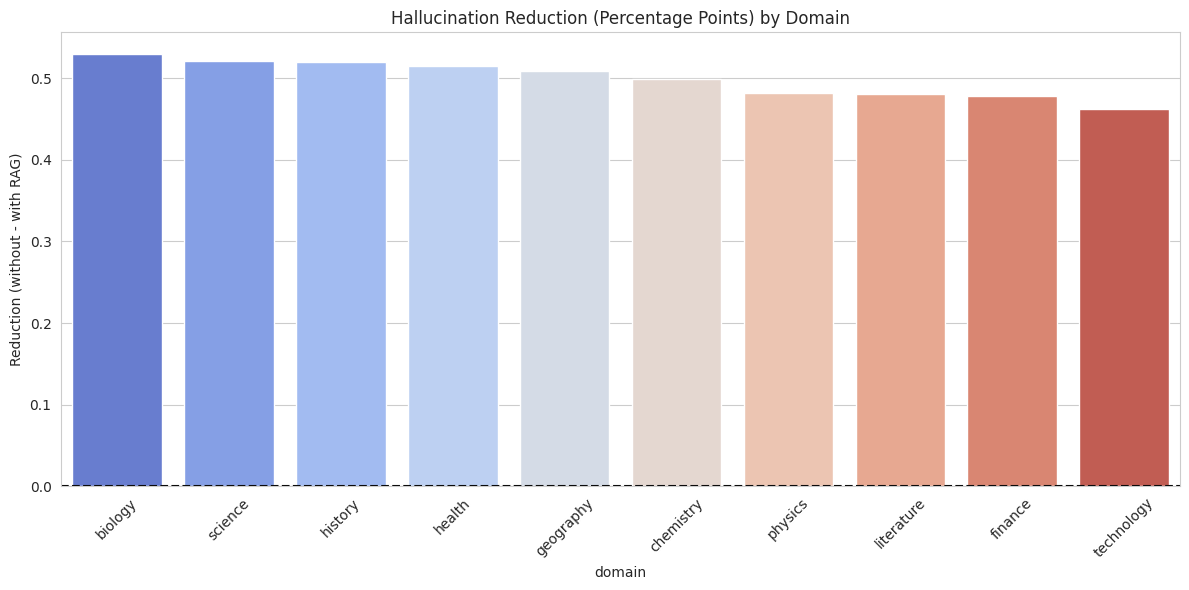

In [18]:
domain_stats_sorted = domain_stats.sort_values('reduction', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=domain_stats_sorted, x='domain', y='reduction', palette='coolwarm')
plt.title('Hallucination Reduction (Percentage Points) by Domain')
plt.xticks(rotation=45)
plt.ylabel('Reduction (without - with RAG)')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Feature Importance & Interpretability

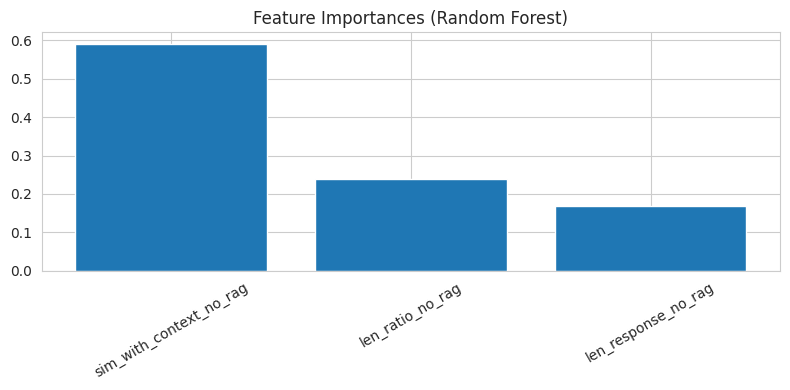

In [19]:
# Feature importance from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = features_realistic

plt.figure(figsize=(8, 4))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feat_names[i] for i in indices], rotation=30)
plt.tight_layout()
plt.show()

# Conclusion

In [20]:
# Final check: overall hallucination rates
print("Without RAG hallucination rate: {:.2%}".format(df['hallucination_label_without_rag'].mean()))
print("With RAG hallucination rate:    {:.2%}".format(df['hallucination_label_with_rag'].mean()))

Without RAG hallucination rate: 57.63%
With RAG hallucination rate:    7.72%


* The dataset clearly shows that RAG dramatically reduces hallucinations (from ~57.6% to ~7.7% in this sample – verify with actual mean).

* We built a **binary classifier** that can detect hallucinations with high accuracy using only the response and retrieved context.

* The most important feature is the **semantic similarity between the response and the retrieved context**, which aligns with RAG's purpose of grounding answers.

* This pipeline can be integrated into a **production LLM application** to flag or filter out potentially hallucinated answers before they reach the user.

**Thank you for exploring this notebook!**
Feel free to extend it with your own features or deep learning models. For production, always consider latency, scalability, and continuous evaluation.

**DO NOT FORGET TO UPVOTE**